In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler

In [59]:
df = pd.read_csv('../data/exercise_dataset.csv')

## Första titt på datan
Visar de första raderna för att få en överblick över struktur och innehåll:

In [60]:
# Förstå datan

df.head()

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3864 entries, 0 to 3863
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  3864 non-null   int64  
 1   Exercise            3864 non-null   object 
 2   Calories Burn       3864 non-null   float64
 3   Dream Weight        3864 non-null   float64
 4   Actual Weight       3864 non-null   float64
 5   Age                 3864 non-null   int64  
 6   Gender              3864 non-null   object 
 7   Duration            3864 non-null   int64  
 8   Heart Rate          3864 non-null   int64  
 9   BMI                 3864 non-null   float64
 10  Weather Conditions  3864 non-null   object 
 11  Exercise Intensity  3864 non-null   int64  
dtypes: float64(4), int64(5), object(3)
memory usage: 362.4+ KB


,ID,Calories Burn,Dream Weight,Actual Weight,Age,Duration,Heart Rate,BMI,Exercise Intensity
count,3864.000000,3864.000000,3864.000000,3864.000000,3864.000000,3864.000000,3864.000000,3864.000000,3864.000000
mean,1932.500000,301.861806,75.139263,75.188440,39.621118,40.190994,139.777950,26.801977,5.457298
std,1115.585048,115.828604,14.545824,14.845511,12.521721,11.765957,23.447528,4.746745,2.850896
min,1.000000,100.009403,50.001984,45.783747,18.000000,20.000000,100.000000,18.500014,1.000000
25%,966.750000,202.168837,62.373585,62.476906,29.000000,30.000000,119.000000,22.686774,3.000000
50%,1932.500000,299.742508,75.522136,75.544407,40.000000,40.000000,140.000000,26.861656,5.000000
75%,2898.250000,404.143688,87.707989,88.105767,51.000000,51.000000,160.000000,30.950380,8.000000
max,3864.000000,499.859262,99.985355,104.309600,60.000000,60.000000,180.000000,34.996639,10.000000


In [61]:
bmi = df['BMI']
actual_weight = df ['Actual Weight']
dream_weight = df ['Dream Weight']

In [62]:
# tar bort NaN
df = df[['BMI', 'Actual Weight', 'Dream Weight']].dropna()

In [63]:
# för att analysera skillnaden -> skapa den
df['Weight_Difference'] = df['Actual Weight'] - df['Dream Weight']

## Kategorisering av viktmål
Vi delar upp individer baserat på om de vill gå upp eller ner i vikt:

In [64]:
df['Weight_Category'] = df['Weight_Difference'].apply(
    lambda x: 'Wants to lose weight' if x > 0 else 'Wants to gain weight'
)

In [65]:
df['Weight_Category'].value_counts()

Weight_Category
Wants to lose weight    1968
Wants to gain weight    1896
Name: count, dtype: int64

## Deskriptiv statistik
Visar grundläggande statistik som medelvärde, min/max och spridning:

In [66]:
# gör statistik
df.describe()

,BMI,Actual Weight,Dream Weight,Weight_Difference
count,3864.000000,3864.000000,3864.000000,3864.000000
mean,26.801977,75.188440,75.139263,0.049177
std,4.746745,14.845511,14.545824,2.851773
min,18.500014,45.783747,50.001984,-4.997348
25%,22.686774,62.476906,62.373585,-2.376211
50%,26.861656,75.544407,75.522136,0.085476
75%,30.950380,88.105767,87.707989,2.533531
max,34.996639,104.309600,99.985355,4.999613


# Val av variabler
Fokuserar på BMI, faktisk vikt och målvikt för att analysera samband och skillnader:

In [67]:
# visar tydligare
print('BMI medel:', df['BMI'].mean())
print('Vikt skillnad medel:', df['Weight_Difference'].mean())

BMI medel: 26.801976636759836
Vikt skillnad medel: 0.0491767494487577


In [68]:
# kollar samband- relationen mellan BMI och vikt
df[['BMI', 'Actual Weight']].corr()

,BMI,Actual Weight
BMI,1.000000,-0.003703
Actual Weight,-0.003703,1.000000


## Avvikande värden (Outliers)
Inga tydliga outliers identifierades i datasetet.

Detta tyder på att datan är jämnt fördelad och saknar extrema värden:

In [69]:
# identifiera outliers
z_scores = np.abs((df['BMI'] - df['BMI'].mean()) / df['BMI'].std())

outliers = df[z_scores > 3]
outliers

,BMI,Actual Weight,Dream Weight,Weight_Difference,Weight_Category


## Visualisering av samband
Ett spridningsdiagram visar relationen mellan BMI och faktisk vikt:

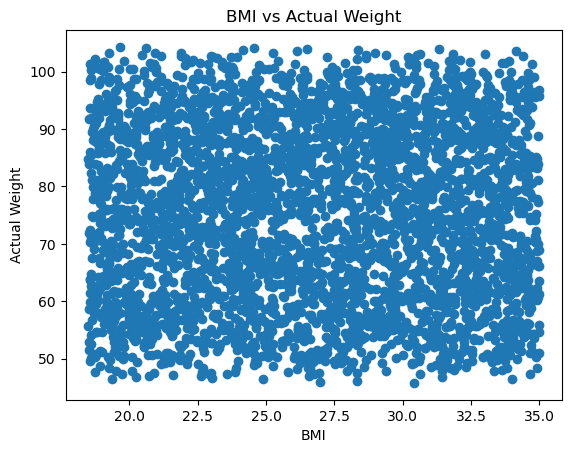

In [70]:
# Scatterplot
plt.scatter(df['BMI'], df['Actual Weight'])
plt.xlabel('BMI')
plt.ylabel('Actual Weight')
plt.title('BMI vs Actual Weight')
plt.show()

## Fördelning av BMI
Visar hur BMI-värdena är fördelade i datasetet:

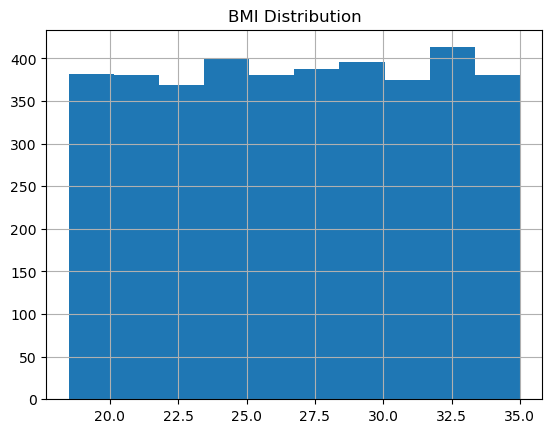

In [71]:
# Histogram
df['BMI'].hist()
plt.title('BMI Distribution')
plt.show()

## Identifiera avvikande värden
Boxplot används för att upptäcka extrema värden i BMI:

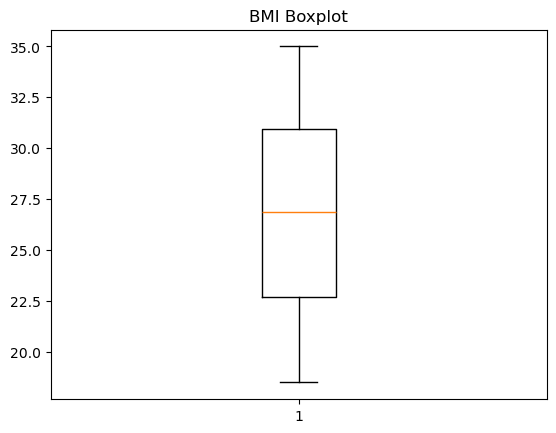

In [72]:
# Boxplot (outliers)
plt.boxplot(df['BMI'])
plt.title('BMI Boxplot')
plt.show()

In [73]:
# Datareduktion - tar bort extrema outliers
df_clean = df[z_scores < 3]

In [74]:
# Skapa Weight_Difference
df['Weight_Difference'] = df['Actual Weight'] - df['Dream Weight']

In [75]:
df['Weight_Category'] = df['Weight_Difference'].apply(
    lambda x: 'Wants to lose weight' if x > 0 else 'Wants to gain weight'
)

In [76]:
df['Weight_Category'].value_counts()

Weight_Category
Wants to lose weight    1968
Wants to gain weight    1896
Name: count, dtype: int64

## Tolkning av vikt-skillnad
I genomsnitt är skillnaden mellan faktisk vikt och målvikt nära noll.

Det innebär att många individer redan ligger nära sin önskade vikt,
men variationen visar att det finns individuella skillnader.

## Interaktiv visualisering
Här visas sambandet mellan BMI och faktisk vikt i en interaktiv graf.
Färg används för att visa om individen vill gå upp eller ner i vikt:

In [77]:
fig = px.scatter(
    df,
    x='BMI',
    y='Actual Weight',
    color='Weight_Category',
    hover_data=['Dream Weight', 'Weight_Difference'],
    title='Interactive: BMI vs Actual Weight'
)

fig.show()

## Bidrag från olika variabler
Här undersöker vi vilka numeriska variabler som har samband med vikt, BMI och skillnaden mellan faktisk vikt och målvikt:

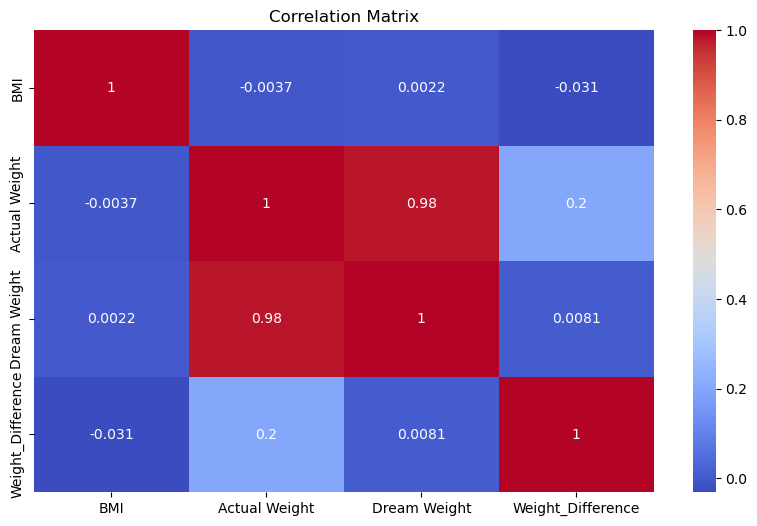

In [78]:
corr_matrix = df[["BMI", "Actual Weight", "Dream Weight", "Weight_Difference"]].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()